```
# Chankin 2014 W-redeposition example
#
# Author: Abdourahmane Diaw
# Copyright (C) 2023-2026 Abdourahmane Diaw, Oak Ridge National Laboratory
# License: GPL-3.0-or-later. Full text in the OpenEdge LICENSE file.
```

# Chankin 2014 (PPCF 56 025003) — W redeposition at the divertor target

Non-redeposition fraction $f_{\rm non\text{-}redep}$ vs
$p=\tau_{\rm ion}\,\omega_{\rm gyro}$, plus individual W orbits.
$B=5.3$ T, $\alpha=3°$, $T_e=100$ eV, flat W target at $z=0$, periodic
laterals. Runs: `./run_chankin.sh [single|multi|full|orbits|all]`.

| case | setup | role |
|---|---|---|
| `single` | single-ioniz, no E | Fussman reference $p^2/(1+p^2)$ |
| `multi` | multi-ioniz, no E | stranded high-Z ions |
| `full` | multi-ioniz + sheath E | Chankin Fig. 6 with-sheath curve |
| `fan` | Fig-3 orbit launch (`particles.dat`) | Chankin Fig. 3 |

In [1]:
import glob, os, re, collections
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

QE=1.602176634e-19; AMU=1.66053907e-27; M_W=183.84*AMU
B_T=5.3; TeV=100.0; DT=5e-9
OMEGA_GYRO=QE*B_T/M_W
print(f"W1+ gyro: omega={OMEGA_GYRO:.3e} rad/s  period={2*np.pi/OMEGA_GYRO*1e6:.3f} us")

W1+ gyro: omega=2.782e+06 rad/s  period=2.259 us


In [2]:
def read_dump(path):
    # k in each track entry = the ACTUAL timestep from the dump header
    # (dump cadence differs between runs: scans use dcad 10, the fan run 2)
    frames=[]; steps=[]; hdr=None; ia=False; ts=False
    for line in open(path):
        if line.startswith("ITEM: TIMESTEP"): ia=False; ts=True; frames.append({}); continue
        if ts: steps.append(int(line.split()[0])); ts=False; continue
        if line.startswith("ITEM: ATOMS"): hdr=line.split()[2:]; ia=True; continue
        if line.startswith("ITEM:"): ia=False; continue
        if ia:
            p=line.split()
            if len(p)==len(hdr):
                d=dict(zip(hdr,p))
                frames[-1][int(d["id"])]=(int(d["type"]),float(d["x"]),float(d["y"]),float(d["z"]))
    tr=collections.defaultdict(list)
    for k,fr in enumerate(frames):
        for pid,v in fr.items(): tr[pid].append((steps[k],)+v)
    return frames,tr

def list_runs():
    return {f.split("redepo.")[-1]:f for f in sorted(glob.glob("state/redepo.*"))}
runs=list_runs()
print("runs:",list(runs))

runs: ['fan', 'full_ne1e19', 'full_ne1e20', 'full_ne1e21', 'full_ne1e22', 'full_ne3e18', 'full_ne3e19', 'full_ne3e20', 'full_ne3e21', 'multi_ne1e19', 'multi_ne1e20', 'multi_ne1e21', 'multi_ne1e22', 'multi_ne3e18', 'multi_ne3e19', 'multi_ne3e20', 'multi_ne3e21', 'single_ne1e19', 'single_ne1e20', 'single_ne1e21', 'single_ne1e22', 'single_ne3e18', 'single_ne3e19', 'single_ne3e20', 'single_ne3e21']


## 1. Individual W orbits — Chankin Fig. 5  (with-sheath run)

Height vs time, coloured by charge state: sputtered W⁰ rises, ionizes, gyrates,
and the sheath returns it to $z=0$.

[full_ne1e19] 2001 frames, 1655 particles


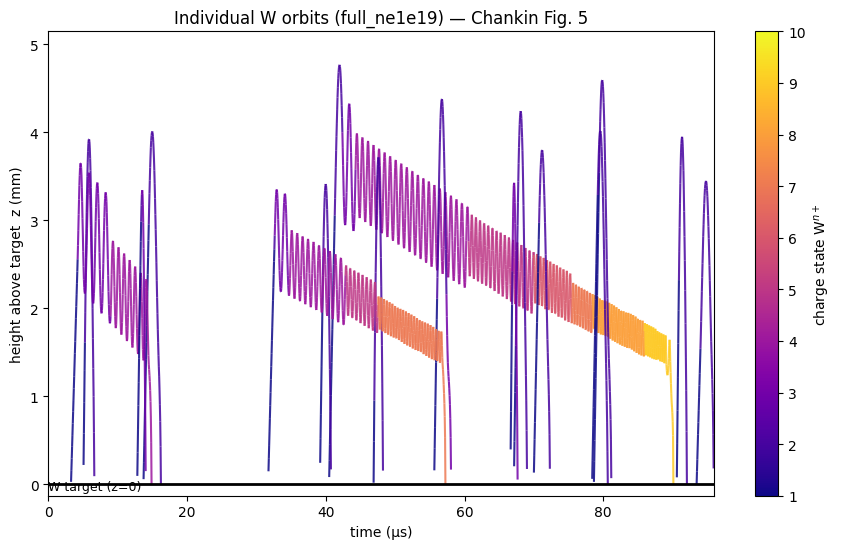

In [3]:
# pick a with-sheath (spatial) run for the orbits
TAG=next((t for t in runs if t.startswith("full_ne1e19")),
     next((t for t in runs if t.startswith("full_")), None))
assert TAG, "no with-sheath scan dumps yet -- run ./run_chankin.sh full"
frames,tracks=read_dump(runs[TAG]); nframe=len(frames)
print(f"[{TAG}] {nframe} frames, {len(tracks)} particles")

sel=[]
for pid,tr in tracks.items():
    ty=[t for _,t,_,_,_ in tr]; z=[zz for *_,zz in tr]
    if max(ty)>1 and len(tr)>=6 and max(z)>1.5e-4 and z[-1]<2e-4:
        sel.append((pid,tr,max(z)))
sel.sort(key=lambda a:-a[2]); sel=sel[:16]

fig,ax=plt.subplots(figsize=(9,5.6)); cmap=plt.get_cmap("plasma"); norm=plt.Normalize(1,10)
for pid,tr,_ in sel:
    t=np.array([k*DT*1e6 for k,*_ in tr]); z=np.array([zz*1e3 for *_,zz in tr]); c=np.array([ty for _,ty,*_ in tr])
    P=np.c_[t,z].reshape(-1,1,2); seg=np.concatenate([P[:-1],P[1:]],axis=1)
    lc=LineCollection(seg,cmap=cmap,norm=norm,lw=1.5,alpha=0.85); lc.set_array(c[:-1]); ax.add_collection(lc)
ax.axhline(0,color="k",lw=2); ax.text(0.02,-0.07,"W target (z=0)",fontsize=9)
ax.set_xlim(0,max(k*DT*1e6 for _,tr,_ in sel for k,*_ in tr)); ax.set_ylim(-0.13,max(m for *_,m in sel)*1.08e3)
ax.set_xlabel("time (µs)"); ax.set_ylabel("height above target  z (mm)")
ax.set_title(f"Individual W orbits ({TAG}) — Chankin Fig. 5")
sm=plt.cm.ScalarMappable(cmap=cmap,norm=norm); sm.set_array([])
fig.colorbar(sm,ax=ax,label="charge state W$^{n+}$",ticks=range(1,11)); plt.tight_layout(); plt.show()

### 1b. A single orbit in real space (Larmor loops + net return)

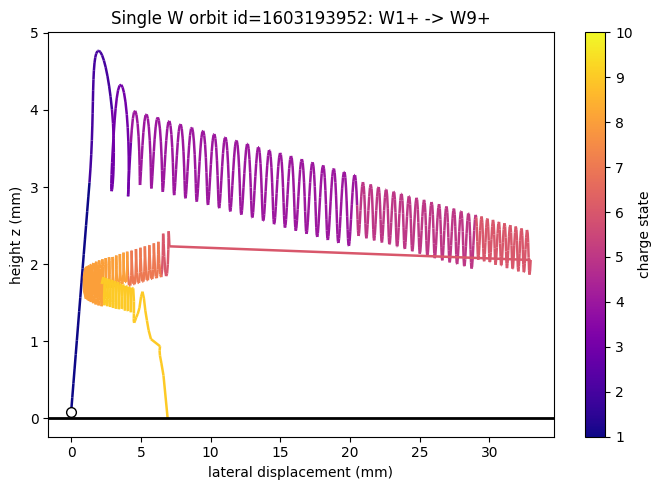

In [4]:
pid,tr,_=sel[0]
x=np.array([xx for _,_,xx,_,_ in tr]); y=np.array([yy for _,_,_,yy,_ in tr])
z=np.array([zz for *_,zz in tr]); c=np.array([ty for _,ty,*_ in tr])
lat=np.hypot(x-x[0],y-y[0])*1e3
fig,ax=plt.subplots(figsize=(7,5))
P=np.c_[lat,z*1e3].reshape(-1,1,2); seg=np.concatenate([P[:-1],P[1:]],axis=1)
lc=LineCollection(seg,cmap="plasma",norm=plt.Normalize(1,10),lw=1.8); lc.set_array(c[:-1]); ax.add_collection(lc); ax.autoscale()
ax.axhline(0,color="k",lw=2); ax.plot(lat[0],z[0]*1e3,"o",ms=7,mfc="w",mec="k")
ax.set_xlabel("lateral displacement (mm)"); ax.set_ylabel("height z (mm)")
ax.set_title(f"Single W orbit id={pid}: W{c.min()}+ -> W{c.max()}+")
sm=plt.cm.ScalarMappable(cmap="plasma",norm=plt.Normalize(1,10)); sm.set_array([])
fig.colorbar(sm,ax=ax,label="charge state",ticks=range(1,11)); plt.tight_layout(); plt.show()

## 2. Parameter $p$ and per-particle redeposition fate

$p=\tau_{\rm ion}\,\omega_{\rm gyro}$ (the launch speed cancels in
$\lambda_{\rm ion}/\rho_{W^+,\max}$). $\tau_{\rm ion}=1/(n_e\langle\sigma v\rangle)$,
so $p\propto1/n_e$; we fix $\langle\sigma v\rangle$ by measuring $\tau_{\rm ion}$
(launch → first ionization) on the lowest-$n_e$ run, then scale.

**Fate is classified per particle from the dumps.** The runs use **periodic
lateral BCs** (infinite target), so the only ways a particle leaves are the
target ($z=0$, redeposited) and the top ($z=2$ cm, escaped). A particle still
airborne at the end of the run (stranded high-Z ion, field-line rider) counts
as **non-redeposited**. Only particles emitted in the first half of the run are
tallied, so every counted particle gets ≥50 µs (≥22 W⁺ gyroperiods) to settle.

Why not absorbing lateral walls + boundary tallies (the earlier approach):
$\rho_{W^+}\sim1$ mm orbits get clipped at the 4 mm-apart x-walls mid-gyration
and are miscounted as escapes — at small $p$ that flooring was ~50% of all
removals, drowning the physics.

In [5]:
def fate_from_dump(path, cut=0.5):
    """Per-particle fate from a periodic-lateral run dump (single light pass).
    redep = vanished at the target; esc = left through the top; air = still
    airborne at the last dumped step. Particles born after cut*run are skipped
    (not enough settle time)."""
    born={}; lastk={}; lastz={}
    cur=0; iid=iz=None; ia=False; ts=False
    for line in open(path):
        if line.startswith("ITEM: TIMESTEP"): ia=False; ts=True; continue
        if ts: cur=int(line.split()[0]); ts=False; continue
        if line.startswith("ITEM: ATOMS"):
            if iid is None:
                h=line.split()[2:]; iid=h.index("id"); iz=h.index("z")
            ia=True; continue
        if line.startswith("ITEM:"): ia=False; continue
        if ia:
            p=line.split()
            if len(p)>iz:
                pid=int(p[iid])
                if pid not in born: born[pid]=cur
                lastk[pid]=cur; lastz[pid]=float(p[iz])
    last=cur; cut_step=cut*last
    dep=esc=air=0
    for pid,b in born.items():
        if b>cut_step: continue
        if lastk[pid]>=last: air+=1          # still airborne -> non-redep
        elif lastz[pid]>0.01: esc+=1         # exited the top  -> non-redep
        else: dep+=1                          # died at target  -> redeposited
    non=esc+air
    return dict(nredep=dep, nesc=esc, nair=air,
                f=non/(non+dep) if (non+dep) else np.nan)

def tau_measured(path):
    _,tracks=read_dump(path); tau=[]
    for pid,tr in tracks.items():
        tr=sorted(tr); ks=[k for k,*_ in tr]; ty=[t for _,t,*_ in tr]
        if ty and ty[0]==1:
            for j in range(1,len(ty)):
                if ty[j]>1: tau.append((ks[j]-ks[0])*DT); break   # ks = actual timesteps
    return np.mean(tau) if tau else np.nan

T={}
for tag,path in runs.items():
    mm=re.match(r"(single|multi|full)_ne([0-9.eE+-]+)$",tag)
    if not mm: continue
    r=fate_from_dump(path); r["smode"]=mm.group(1); r["ne"]=float(mm.group(2))
    T[(r["smode"],r["ne"])]=r

# calibrate <sigma v> from the lowest-ne dump we have (ionization is sheath-independent)
ne_dump={}
for tag,path in runs.items():
    mm=re.match(r"(\w+)_ne([0-9.eE+-]+)",tag)
    if mm: ne_dump[float(mm.group(2))]=path
assert ne_dump, "no scan dumps yet -- run ./run_chankin.sh first"
ne_lo=min(ne_dump); tau_lo=tau_measured(ne_dump[ne_lo]); SIGV=1.0/(ne_lo*tau_lo)
for r in T.values(): r["p"]=OMEGA_GYRO/(r["ne"]*SIGV)
print(f"calibration: ne={ne_lo:.0e} tau_meas={tau_lo*1e6:.3f} us -> <sigma v>={SIGV:.2e} m^3/s")
for smode in ("single","multi","full"):
    rows=sorted([r for (m,ne),r in T.items() if m==smode],key=lambda r:r["ne"])
    if not rows: continue
    print(f"\n {smode:8}: {'ne':>8} {'p':>8} {'analytic':>9} {'f_nonredep':>11} {'redep':>7} {'top_esc':>8} {'airborne':>9}")
    for r in rows:
        fa=r['p']**2/(1+r['p']**2)
        print(f"          {r['ne']:8.0e} {r['p']:8.4f} {fa:9.3f} {r['f']:11.3f} {r['nredep']:7d} {r['nesc']:8d} {r['nair']:9d}")

calibration: ne=3e+18 tau_meas=0.942 us -> <sigma v>=3.54e-13 m^3/s

 single  :       ne        p  analytic  f_nonredep   redep  top_esc  airborne
             3e+18   2.6206     0.873       0.432     491       15       359
             1e+19   0.7862     0.382       0.236     661        7       197
             3e+19   0.2621     0.064       0.114     766        4        95
             1e+20   0.0786     0.006       0.068     806        3        56
             3e+20   0.0262     0.001       0.060     812        3        49
             1e+21   0.0079     0.000       0.056     816        3        45
             3e+21   0.0026     0.000       0.056     816        3        45
             1e+22   0.0008     0.000       0.056     816        3        45

 multi   :       ne        p  analytic  f_nonredep   redep  top_esc  airborne
             3e+18   2.6206     0.873       0.484     446       16       403
             1e+19   0.7862     0.382       0.385     531        7       326
    

## $f_{\rm non\text{-}redep}$ vs $p$ — Chankin Fig. 6

Three scans against the Fussman law $p^2/(1+p^2)$: `single` should track it
(residual floor at small $p$ = the $\alpha=3°$ parallel channel); `multi`
stays high at small $p$ (fast multiple ionization strands high-Z ions,
$\rho\propto1/Z$); `full` drops far below (the MPS/DS force $\propto Z$ acts
hardest on exactly those ions).

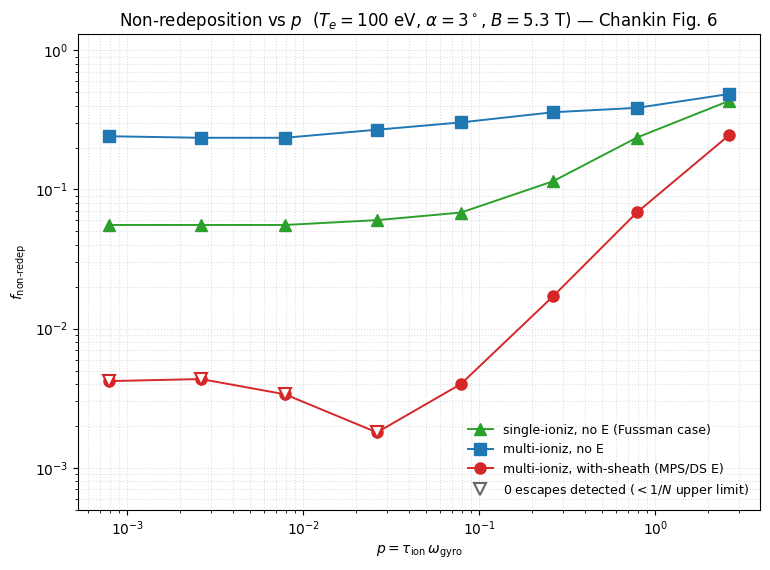

In [6]:
fig,ax=plt.subplots(figsize=(7.8,5.8))
# pp=np.logspace(-3,1.4,200); ax.plot(pp,pp**2/(1+pp**2),"k-",lw=2,
        # label=r"Fussman $p^2/(1+p^2)$ (geometry, no E)")
styles={"single":dict(color="C2",marker="^",label="single-ioniz, no E (Fussman case)"),
        "multi":dict(color="C0",marker="s",label="multi-ioniz, no E"),
        "full":dict(color="C3",marker="o",label="multi-ioniz, with-sheath (MPS/DS E)")}
for smode,st in styles.items():
    rows=sorted([r for (m,ne),r in T.items() if m==smode and np.isfinite(r.get("p",np.nan))],
                key=lambda r:r["p"])
    if not rows: continue
    N=[r["nredep"]+r["nesc"]+r["nair"] for r in rows]
    # zero-count points are censored on a log axis: draw them at the 1/N
    # upper limit with an open downward marker
    fplot=[r["f"] if r["f"]>0 else 1.0/n for r,n in zip(rows,N)]
    ax.plot([r["p"] for r in rows],fplot,"-",ms=8,lw=1.4,
            color=st["color"],marker=st["marker"],label=st["label"])
    cens=[(r["p"],1.0/n) for r,n in zip(rows,N) if r["f"]==0]
    if cens:
        ax.plot(*zip(*cens),ls="none",marker="v",ms=9,mfc="w",mec=st["color"],mew=1.5)
ax.plot([],[],ls="none",marker="v",ms=9,mfc="w",mec="0.4",mew=1.5,
        label=r"0 escapes detected ($<1/N$ upper limit)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$p=\tau_{\rm ion}\,\omega_{\rm gyro}$"); ax.set_ylabel(r"$f_{\rm non\text{-}redep}$")
ax.set_title(r"Non-redeposition vs $p$  ($T_e=100$ eV, $\alpha=3^\circ$, $B=5.3$ T) — Chankin Fig. 6")
ax.set_ylim(5e-4,1.3); ax.grid(True,which="both",ls=":",alpha=0.4); ax.legend(frameon=False,loc="lower right",fontsize=9)
plt.tight_layout(); plt.show()

## Single-atom orbits — Chankin Fig. 3

`./run_chankin.sh orbits` launches the 5 atoms in `particles.dat`
($\alpha=0$, $n_e=10^{21}$, no sheath, multi-ionization) and writes
`state/redepo.fan`. Each ion spirals up while climbing charge states
($\rho\propto1/Z$), the multi-loop spiral of Chankin's Fig. 3.

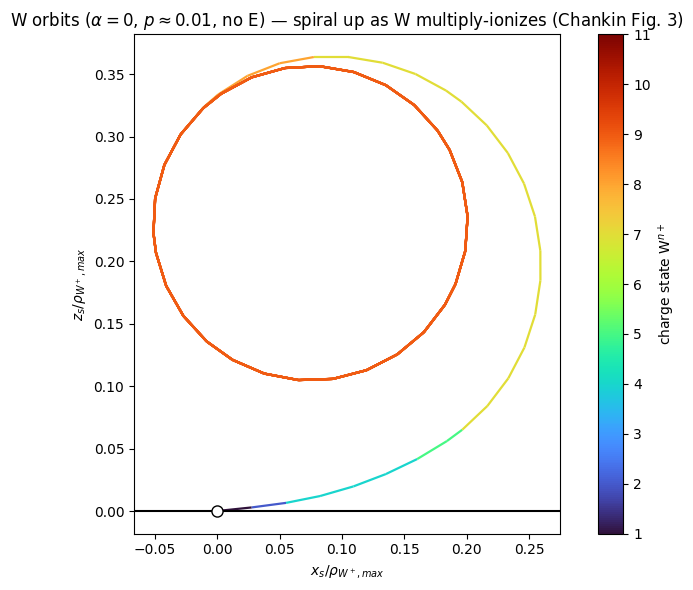

1 orbits; charge reached: id1->W8+


In [7]:
# --- gyro-plane orbits (x-z, perpendicular to B=+y), normalized to rho_W+,max ---
QE=1.602176634e-19; M_W=183.84*1.66053907e-27; B_FLD=5.3
FAN="state/redepo.fan"
if not os.path.exists(FAN):
    print("run the Fig-3 launch first (see command above) to create", FAN)
else:
    tr=collections.defaultdict(list); hdr=None; ia=False
    for line in open(FAN):
        if line.startswith("ITEM: ATOMS"): hdr=line.split()[2:]; ia=True; continue
        if line.startswith("ITEM:"): ia=False; continue
        if ia:
            p=line.split()
            if len(p)==len(hdr):
                d=dict(zip(hdr,p)); tr[int(d["id"])].append([float(d[k]) for k in ("type","x","z","vx","vz")])
    fig,ax=plt.subplots(figsize=(8,6)); cmap=plt.get_cmap("turbo"); norm=plt.Normalize(1,11)
    for pid,rows in sorted(tr.items()):
        a=np.array(rows); ty,x,z,vx,vz=a.T
        rho=M_W*np.hypot(vx[0],vz[0])/(QE*B_FLD)           # W+ Larmor radius at launch
        xs=(x-x[0])/rho; ys=(z-z[0])/rho
        seg=np.concatenate([np.c_[xs,ys].reshape(-1,1,2)[:-1],np.c_[xs,ys].reshape(-1,1,2)[1:]],axis=1)
        lc=LineCollection(seg,cmap=cmap,norm=norm,lw=1.6); lc.set_array(ty[:-1]); ax.add_collection(lc)
    ax.autoscale(); ax.axhline(0,color="k",lw=1.5); ax.plot(0,0,"o",mfc="w",mec="k",ms=8)
    ax.set_aspect("equal"); ax.set_xlabel(r"$x_s/\rho_{W^+,max}$"); ax.set_ylabel(r"$z_s/\rho_{W^+,max}$")
    ax.set_title(r"W orbits ($\alpha=0$, $p\approx0.01$, no E) — spiral up as W multiply-ionizes (Chankin Fig. 3)")
    sm=plt.cm.ScalarMappable(cmap=cmap,norm=norm); sm.set_array([])
    fig.colorbar(sm,ax=ax,label="charge state W$^{n+}$",ticks=range(1,12))
    plt.tight_layout(); plt.show()
    print(f"{len(tr)} orbits; charge reached: "+
          ", ".join(f"id{p}->W{int(np.array(r)[:,0].max())-1}+" for p,r in sorted(tr.items())))

### Notes

- The no-sheath → with-sheath gap is the physics of interest: the MPS/DS
  field returns the stranded high-Z ions.
- `multi` above the Fussman law at small $p$ is expected — Fussman assumes a
  single ionization.
- Periodic laterals matter: absorbing x-walls clip ~1 mm orbits in the 4 mm
  box and floor $f_{\rm non\text{-}redep}$ near 0.4.
- Runs need `nemit 1`; scans made before 2026-07-23 also predate the sheath
  φ-blend fix in `sheath_models.cpp` and were discarded.
- ~$\pm0.01$–0.03 per point; more densities: extend `NE_LIST` in
  `run_chankin.sh`.